In [3]:
# Linear programming-maximum profit
# A factory produces two products A and B 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog 

In [4]:
data={
    "product":["A","B"],
    "profit":[5,4],
    "Raw_material":[6,4],
    "work_hours":[1,2]
}
df=pd.DataFrame(data)
print(df)

  product  profit  Raw_material  work_hours
0       A       5             6           1
1       B       4             4           2


In [5]:
# solve with scipy linprog
# linprog minimize , so wz negate profit to maximize
c=[-5,-4]

# constraints : Ax<=b

A=[[6,4],   #Raw material : 6A+4B<=24
   [1,2]]   #work hours : A+2B<=6

b=[24,6]

# bounds: A<=0 , B<=0

x_bounds=(0,None)
y_bounds=(0,None)

result=linprog(c , A_ub=A , b_ub=b , bounds=[x_bounds, y_bounds])

print("product A: ",round(result.x[0],2))
print("product B: ",round(result.x[1],2))
print("max profit: ",round(-result.fun,2))

product A:  3.0
product B:  1.5
max profit:  21.0


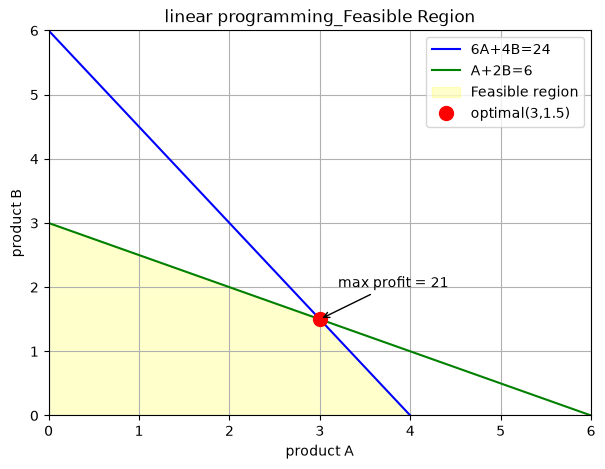

In [6]:
# plot the feasible region
x=np.linspace(0,6,300)

# constraints lines
c1=(24-6*x)/4   #6A+4B=24
c2=(6-x)/2      #A+2B=6

plt.figure(figsize=(7,5))

# constraint lines
plt.plot(x, c1, label="6A+4B=24", color="blue")
plt.plot(x, c2, label="A+2B=6", color="green")

# feasible region

y_feasible=np.minimum(c1,c2)
y_feasible=np.maximum(y_feasible,0)

plt.fill_between(x, y_feasible, alpha=0.2 , color="yellow" , label="Feasible region")

#optimal point

plt.plot(3 , 1.5, "ro" , markersize=10 , label="optimal(3,1.5)")

plt.annotate("max profit = 21" , xy=(3,1.5) , xytext=(3.2,2) , arrowprops=dict(arrowstyle="->"))

plt.xlim(0,6)
plt.ylim(0,6)
plt.xlabel("product A")
plt.ylabel("product B")
plt.title("linear programming_Feasible Region")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
#result summary
results={
    "product " :["A","B"],
    "units " :[round(result.x[0],2) ,  round(result.x[1],2)],
    "profit/units " :[5,4],
    "total profit " :[round(result.x[0]*5,2) ,  round(result.x[1]*4,2)]
}
df_results=pd.DataFrame(results)
print(df_results)
print("\n max total profit: ",round(-result.fun,2))

  product   units   profit/units   total profit 
0        A     3.0              5           15.0
1        B     1.5              4            6.0

 max total profit:  21.0
